<a href="https://colab.research.google.com/github/Khuongtdm/ImagineRegconition/blob/main/computerVison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn

import torchvision
from torchvision import transforms
from torchvision.transforms import ToTensor
from torchvision import datasets

import matplotlib.pyplot as plt
import numpy as np

In [ ]:
import requests
from pathlib import Path

if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open ("helper_functions.py", "wb") as f:
    f.write(request.content)

In [ ]:
train_data = datasets.FashionMNIST(
    root = 'data',
    train = True,

    download = True,
    transform =torchvision.transforms.ToTensor(),
    target_transform= None
)
test_data = datasets.FashionMNIST(
    root = 'data',
    train = False,
    transform =torchvision.transforms.ToTensor(),
    download=True,
    target_transform= None
)

In [ ]:
len(train_data), len(test_data)

(60000, 10000)

In [ ]:
image, label = train_data[0]
image, label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

In [ ]:
class_names = train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [ ]:
class_tidx = train_data.class_to_idx
class_tidx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

In [ ]:
train_data.targets, len(train_data.targets)

(tensor([9, 0, 0,  ..., 3, 0, 5]), 60000)

In [ ]:
print(f"Image shape: {image.shape} ->[colorChannels, height, width]")
print(f"Label: {class_names[label]}")

Image shape: torch.Size([1, 28, 28]) ->[colorChannels, height, width]
Label: Ankle boot


(-0.5, 27.5, 27.5, -0.5)

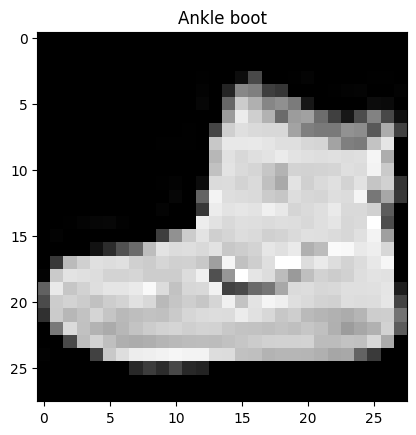

In [ ]:
import matplotlib.pyplot as plt
image, label = train_data[0]
plt.imshow(image.squeeze(), cmap="gray")
plt.title(class_names[label])
plt.axis("on")

(-0.5, 27.5, 27.5, -0.5)

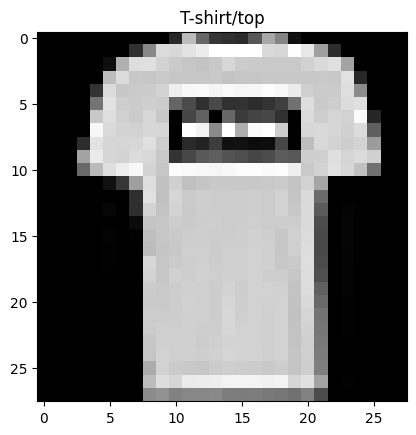

In [ ]:
image, label = train_data[1]
plt.imshow(image.squeeze(), cmap="gray")
plt.title(class_names[label])
plt.axis("on")

(-0.5, 27.5, 27.5, -0.5)

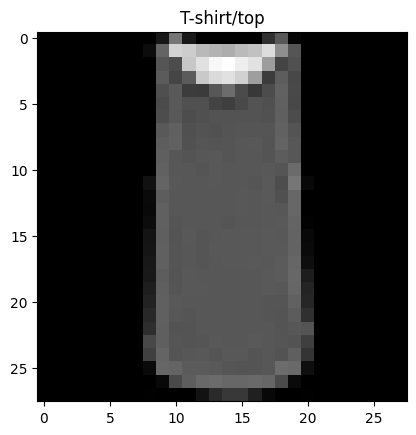

In [ ]:
image, label = train_data[2]
plt.imshow(image.squeeze(), cmap="gray")
plt.title(class_names[label])
plt.axis("on")

(-0.5, 27.5, 27.5, -0.5)

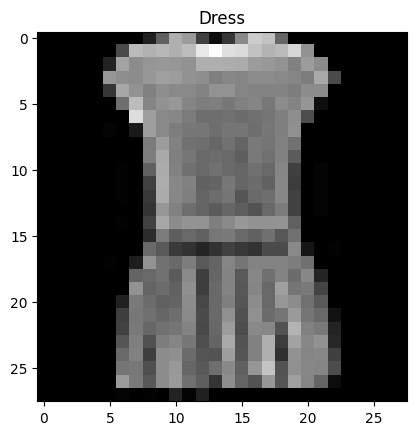

In [ ]:
image, label = train_data[3]
plt.imshow(image.squeeze(), cmap="gray")
plt.title(class_names[label])
plt.axis("on")

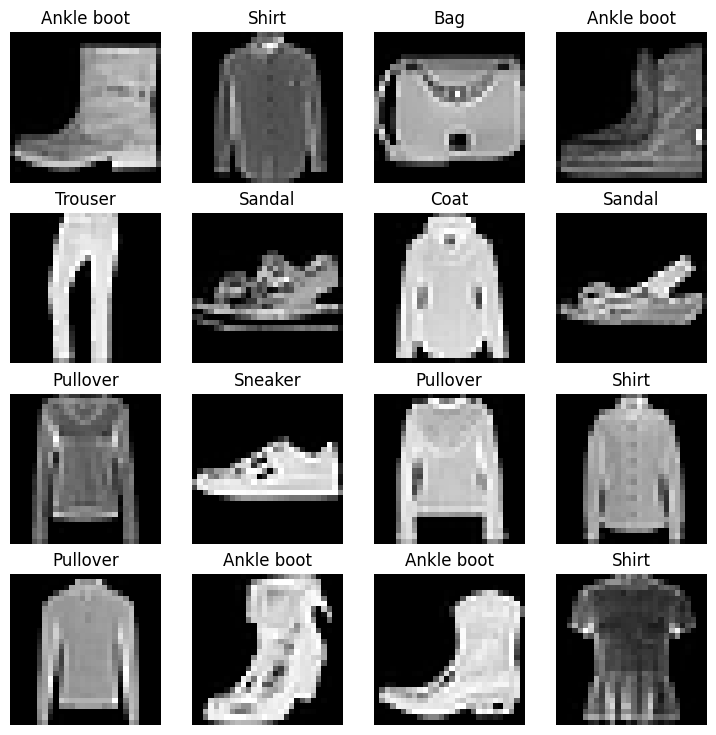

In [ ]:
torch.manual_seed(42)
fig= plt.figure(figsize=(9,9))
rows, cols = 4,4
for i in range(1, rows * cols +1):
    random_idx = torch.randint(0, len(train_data), size=[1]).item()
    image, label = train_data[random_idx]
    fig.add_subplot(rows, cols, i)#i for index
    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(class_names[label])
    plt.axis("off")


In [ ]:
train_data, test_data

(Dataset FashionMNIST
     Number of datapoints: 60000
     Root location: data
     Split: Train
     StandardTransform
 Transform: ToTensor(),
 Dataset FashionMNIST
     Number of datapoints: 10000
     Root location: data
     Split: Test
     StandardTransform
 Transform: ToTensor())

In [ ]:
from torch.utils.data import DataLoader
BATCH_SIZE = 32
train_dataloader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)
train_dataloader, test_dataloader


(<torch.utils.data.dataloader.DataLoader at 0x7e0d312b77c0>,
 <torch.utils.data.dataloader.DataLoader at 0x7e0d312b7700>)

In [ ]:
print(f"Dataloaders: {train_dataloader, test_dataloader}")
print(f"Length of train dataloader: {len(train_dataloader)} batches of {BATCH_SIZE}")
print(f"Length of train dataloader: {len(test_dataloader)} batches of {BATCH_SIZE}")

Dataloaders: (<torch.utils.data.dataloader.DataLoader object at 0x7e0d312b77c0>, <torch.utils.data.dataloader.DataLoader object at 0x7e0d312b7700>)
Length of train dataloader: 1875 batches of 32
Length of train dataloader: 313 batches of 32


In [ ]:
train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

Label: Bag
Shape: torch.Size([1, 28, 28])


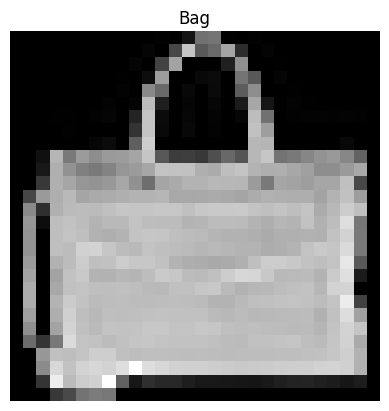

In [ ]:
random_idx = torch.randint(0, len(train_features_batch), size=[1]).item()
img, label = train_features_batch[random_idx], train_labels_batch[random_idx]
plt.imshow(img.squeeze(), cmap="gray")
plt.title(class_names[label])
plt.axis("off")
print(f"Label: {class_names[label]}")
print(f"Shape: {img.shape}")

In [ ]:
flatten_model = nn.Flatten()
x = train_features_batch[0]
output = flatten_model(x)
print(f"Shape before flattening: {x.shape}")
print(f"Shape after flattening: {output.shape}")

Shape before flattening: torch.Size([1, 28, 28])
Shape after flattening: torch.Size([1, 784])


In [ ]:
from torch import nn
class FashionMNISTModelV0(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_shape, out_features=hidden_units),
            nn.Linear(in_features=hidden_units, out_features=output_shape)
        )
    def forward(self, x: torch.Tensor):
        return self.layer_stack(x)

In [ ]:
torch.manual_seed(42)
model_0 = FashionMNISTModelV0(input_shape=784, hidden_units=10, output_shape=len(class_names)).to("cpu")
model_0


FashionMNISTModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [ ]:
model_0.state_dict()

OrderedDict([('layer_stack.1.weight',
              tensor([[ 0.0273,  0.0296, -0.0084,  ..., -0.0142,  0.0093,  0.0135],
                      [-0.0188, -0.0354,  0.0187,  ..., -0.0106, -0.0001,  0.0115],
                      [-0.0008,  0.0017,  0.0045,  ..., -0.0127, -0.0188,  0.0059],
                      ...,
                      [-0.0116,  0.0273, -0.0344,  ...,  0.0176,  0.0283, -0.0011],
                      [-0.0230,  0.0257,  0.0291,  ..., -0.0187, -0.0087,  0.0001],
                      [ 0.0176, -0.0147,  0.0053,  ..., -0.0336, -0.0221,  0.0205]])),
             ('layer_stack.1.bias',
              tensor([-0.0093,  0.0283, -0.0033,  0.0255,  0.0017,  0.0037, -0.0302, -0.0123,
                       0.0018,  0.0163])),
             ('layer_stack.2.weight',
              tensor([[ 0.0614, -0.0687,  0.0021,  0.2718,  0.2109,  0.1079, -0.2279, -0.1063,
                        0.2019,  0.2847],
                      [-0.1495,  0.1344, -0.0740,  0.2006, -0.0475, -0.2514, -0.

In [ ]:
from helper_functions import accuracy_fn
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.1)

In [ ]:
from timeit import default_timer as timer
def print_train_time(start: float, end: float, device: torch.device = None):
    total_time = end - start
    print(f"Train time on {device}: {total_time:.3f} seconds")
    return total_time

In [ ]:
start_time = timer()
end_time = timer()
print_train_time(start_time, end_time, "cpu")

In [ ]:
from tqdm.auto import tqdm
torch.manual_seed(42)
 #training loop
epochs = 3
for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}\n-------")
  train_loss = 0


  for batch, (X, y) in enumerate(train_dataloader):
      model_0.to("cpu")

      y_pred = model_0(X)
      loss = loss_fn(y_pred, y)
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()
      if batch % 400 == 0:
          print(f"Looked at {batch * len(X)}/{len(train_dataloader.dataset)} samples")
      train_loss += loss.item()

  train_loss /= len(train_dataloader)
  #testing
  test_loss, test_acc = 0, 0
  model_0.eval()
  with torch.inference_mode():
    for X, y in test_dataloader:
        y_pred = model_0(X)
        test_loss += loss_fn(y_pred, y)
        test_acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))

    test_loss /= len(test_dataloader)
    test_acc /= len(test_dataloader)
    print(f"Train loss: {train_loss:.5f} | Test loss: {test_loss:.5f} | Test acc: {test_acc:.2f}")
  train_time_end = timer()
  total_train_time = print_train_time(start_time, train_time_end, "cpu")



In [ ]:
torch.manual_seed(42)
def eval_model(model: nn.Module, data_loader: torch.utils.data.DataLoader, loss_fn: nn.Module,accuracy_fn):
  loss, acc = 0, 0
  model.eval()
  with torch.inference_mode():
    for X, y in tqdm(data_loader):
      y_pred = model(X)
      loss += loss_fn(y_pred, y)
      acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))
    loss /= len(data_loader)
    acc /= len(data_loader)
    print(f"Loss: {loss:.5f} | Accuracy: {acc:.2f}")
  return {"model_name": model.__class__.__name__, "model_loss": loss.item(), "model_acc": acc}

model_0_results = eval_model(model=model_0, data_loader=test_dataloader, loss_fn=loss_fn,accuracy_fn=accuracy_fn)
model_0_results


  0%|          | 0/313 [00:00<?, ?it/s]

Loss: 2.31906 | Accuracy: 10.85


{'model_name': 'FashionMNISTModelV0',
 'model_loss': 2.3190648555755615,
 'model_acc': 10.852635782747603}

In [ ]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
device

In [ ]:
!nvidia-smi

In [ ]:
class FashionMNISTModelV1(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()

        self.flat =nn.Flatten()
        self.l1= nn.Linear(in_features=input_shape, out_features=hidden_units)

        self.relu = nn.ReLU()
        self.l2 = nn.Linear(in_features=hidden_units, out_features=output_shape)


    def forward(self, x: torch.Tensor):
        return self.relu(self.l2(self.relu(self.l1(self.flat(x)))))

In [ ]:
torch.manual_seed(42)
model_1 = FashionMNISTModelV1(input_shape=784, hidden_units=10, output_shape=len(class_names)).to(device)
next(model_1.parameters()).device

In [ ]:
from helper_functions import accuracy_fn
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_1.parameters(), lr=0.1)

NameError: name 'model_1' is not defined

In [ ]:
def train_step(model, train_dataloader, loss_fn, optimizer, accuracy_fn,device):
    train_loss, train_acc = 0,0
    model.train()
    for batch, (X, y) in enumerate(train_dataloader):
        X, y = X.to(device), y.to(device)
        y_pred = model(X)

        #cal loss
        loss = loss_fn(y_pred, y)
        train_loss += loss
        train_acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))

        #optimizer
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        #print
        if batch % 400 == 0:
            print(f"Looked at {batch * len(X)}/{len(train_dataloader.dataset)} samples")
    train_loss /= len(train_dataloader)
    train_acc /= len(train_dataloader)
    return (train_acc, train_loss)
def test_step(model, test_dataloader, loss_fn,optimizer, accuracy_fn,device):
  test_loss, test_acc = 0, 0
  model.eval()
  with torch.inference_mode():
    for X, y in test_dataloader:

      X, y = X.to(device), y.to(device)

      y_pred = model(X)

      test_loss += loss_fn(y_pred, y)
      test_acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))
    test_loss /= len(test_dataloader)
    test_acc /= len(test_dataloader)
    return (test_acc, test_loss)

In [ ]:
from tqdm.auto import tqdm
from timeit import default_timer as timer
epochs = 3
def train_loop(model, train_dataloader, test_dataloader, optimizer, loss_fn, accuracy_fn, epochs):
    start_time = timer()
    for epoch in tqdm(range(epochs)):
        train_acc,train_loss = train_step(model, train_dataloader, loss_fn, optimizer, accuracy_fn,device)

        test_acc,test_loss = test_step(model, test_dataloader, loss_fn, optimizer, accuracy_fn, device)
        print(f"Epoch: {epoch} | Train loss: {train_loss:.5f} | Train acc: {train_acc:.2f} | Test loss: {test_loss:.5f} | Test acc: {test_acc:.2f}")

    end_time = timer()
    total_time = print_train_time(start_time, end_time, device)
    return {"Module name": model.__class__.__name__, "model_loss": test_loss, "model_acc": test_acc, "model_time": end_time-start_time}



In [ ]:
train_loop(model_1, train_dataloader, test_dataloader, optimizer, loss_fn, accuracy_fn, epochs)

In [ ]:
model_0=model_0.to(device)
train_loop(model_0, train_dataloader, test_dataloader, optimizer, loss_fn, accuracy_fn, epochs)

In [ ]:
import torch
from torch import nn
device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
class FashionMNISTModelV2(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape, out_channels=hidden_units, kernel_size=3,stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3,stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.block_2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3,stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3,stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units*7*7, out_features=output_shape)
        )
    def forward(self, x: torch.Tensor):
        x = self.block_1(x)

        x = self.block_2(x)

        x = self.classifier(x)



        return x


In [ ]:
len(class_names)

10

In [ ]:
torch.manual_seed(42)
model_2 = FashionMNISTModelV2(input_shape=1, hidden_units=10, output_shape=len(class_names)).to(device)


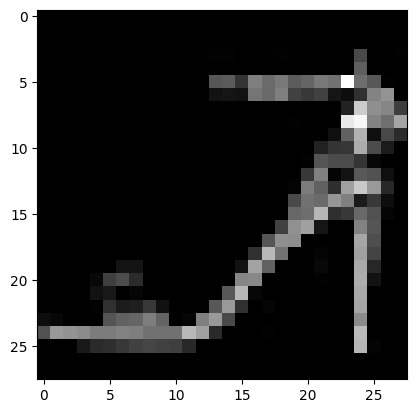

In [ ]:
plt.imshow(train_features_batch[0].squeeze(), cmap="gray")

In [ ]:
img.shape

torch.Size([1, 28, 28])

In [ ]:
model_2(img.to(device).unsqueeze(dim=0))

torch.Size([1, 10, 14, 14])
torch.Size([1, 10, 7, 7])
torch.Size([1, 10])


tensor([[ 0.0283, -0.0637,  0.0533, -0.0330, -0.0185,  0.0103, -0.0061, -0.0090,
          0.0229,  0.0085]], device='cuda:0', grad_fn=<AddmmBackward0>)

In [ ]:
image= img.to(device)

In [ ]:
torch.manual_seed(42)
image = torch.randn(size=(32, 1, 28, 28))
test_image = image[0]
print(f"Image shape: {image.shape}")
print(f"Image device: {test_image.device}")

Image shape: torch.Size([32, 1, 28, 28])
Image device: cpu


In [ ]:
conv_layer = nn.Conv2d(in_channels=1, out_channels=10, kernel_size=3, stride=1, padding=0)
conv_out = conv_layer(test_image.unsqueeze(dim=0))
conv_out.shape

torch.Size([1, 10, 26, 26])

In [ ]:
print(f"test image shape: {test_image.shape}")
print(f"test inmage unsqueezed shape: {test_image.unsqueeze(dim=0).shape}")
conv_out =conv_layer(test_image.unsqueeze(dim=0))
print(f"conv_out shape: {conv_out.shape}")
maxpool_layer = nn.MaxPool2d(2)
pool_out = maxpool_layer(conv_out)
print(f"pool_out shape: {pool_out.shape}")


test image shape: torch.Size([1, 28, 28])
test inmage unsqueezed shape: torch.Size([1, 1, 28, 28])
conv_out shape: torch.Size([1, 10, 26, 26])
pool_out shape: torch.Size([1, 10, 13, 13])


In [ ]:
rand_tensor = torch.randn(size=(1, 1, 2, 2))
a = maxpool_layer((rand_tensor))
rand_tensor, a


(tensor([[[[-1.2703,  1.3130],
           [ 0.8790,  2.2157]]]]),
 tensor([[[[2.2157]]]]))

In [ ]:
model_2 = FashionMNISTModelV2(1,10,len(class_names)).to(device)
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(params=model_2.parameters(), lr=0.1)
m2Res = train_loop(model_2, train_dataloader, test_dataloader, optimizer, loss_fn, accuracy_fn, epochs)

  0%|          | 0/3 [00:00<?, ?it/s]

Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Epoch: 0 | Train loss: 0.95024 | Train acc: 64.71 | Test loss: 0.42739 | Test acc: 84.15
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Epoch: 1 | Train loss: 0.37132 | Train acc: 86.65 | Test loss: 0.34933 | Test acc: 87.62
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Epoch: 2 | Train loss: 0.32894 | Train acc: 88.07 | Test loss: 0.32183 | Test acc: 88.42
Train time on cuda: 37.493 seconds


In [ ]:
imgInd = 70
plt.imshow(test_data[imgInd][0].squeeze(),cmap="gray")
sample = torch.unsqueeze(test_data[imgInd][0], dim=0).to(device)
result = model_2(sample)
result= torch.softmax(result.squeeze(0), dim=0)
print(result)
resultbutMore = result.argmax(dim=0)
print(test_data.classes)
plt.title(class_names[test_data[imgInd][1]] + " " + class_names[resultbutMore.item()])


NameError: name 'plt' is not defined